# DRPG Beauty Failure Diagnosis

This notebook documents the failed DRPG Beauty run `drpg_beauty_lr003_s6_h100-23935474` against the available RPG Beauty baseline. It parses the repo-local training logs, builds metric tables and plots, and records concrete hypotheses for follow-up jobs.

The goal is to separate three possible causes:

1. Operational failure: the Slurm job, environment, data cache, or checkpoint handling failed.
2. Training/objective failure: the denoiser learns a weak semantic-ID predictor.
3. Decoding/ranking failure: the denoiser learns something useful, but iterative denoising or item scoring destroys it.

Current high-level read: the run completed normally, but DRPG validation quality is far below RPG long before final test-time graph propagation. That makes this primarily a model/objective/decoding diagnosis, not an H100 or scheduler issue.

In [1]:
from __future__ import annotations

import ast
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "AGENTS.md").is_file() and (candidate / "models").is_dir():
            return candidate
    raise RuntimeError("Could not locate repo root from current working directory.")


REPO_ROOT = find_repo_root()

DRPG_STDERR = REPO_ROOT / "output/diffuser/train/drpg_beauty_lr003_s6_h100-23935474.err"
DRPG_STDOUT = REPO_ROOT / "output/diffuser/train/drpg_beauty_lr003_s6_h100-23935474.out"
DRPG_LOG = REPO_ROOT / "artifacts/rpg/logs/AmazonReviews2014/DRPG/drpg_beauty_lr003_s6_h100-scripts|rpg.py_--model_DRPG_--preset_beauty_--run_id_drpg_beauty_lr003_s6_h100_--diffusion_mask_counts_32,24,16,8,4,1_--lr_0.003-Jun-16-2026_17-12-d0ed4f.log"
RPG_LOG = REPO_ROOT / "artifacts/rpg/logs/AmazonReviews2014/RPG/rpg_repro_beauty-scripts|rpg.py_--preset_beauty-Jun-05-2026_15-10-e7b432.log"

RUNS = {
    "RPG baseline": RPG_LOG,
    "DRPG lr003 s6 h100": DRPG_LOG,
}

RUN_MANIFEST = pd.DataFrame(
    [
        {"run": name, "log_path": str(path.relative_to(REPO_ROOT)), "exists": path.is_file()}
        for name, path in RUNS.items()
    ]
)
RUN_MANIFEST


,run,log_path,exists
0,RPG baseline,artifacts/rpg/logs/AmazonReviews2014/RPG/rpg_r...,True
1,DRPG lr003 s6 h100,artifacts/rpg/logs/AmazonReviews2014/DRPG/drpg...,True


In [2]:
METRIC_RE = re.compile(r"\[Epoch (?P<epoch>\d+)\] (?P<split>Val|Train) (?P<label>Results|Loss): (?P<body>.*)")
TEST_RE = re.compile(r"Test Results: (?P<body>OrderedDict\(.*\))")
BEST_RE = re.compile(r"Best epoch: (?P<epoch>\d+), Best val score: (?P<score>[0-9.eE+-]+)")
CKPT_RE = re.compile(r"Loaded best model checkpoint from (?P<path>.*)")


def parse_ordered_dict(raw: str) -> dict[str, float]:
    match = re.search(r"OrderedDict\((\[.*\])\)", raw)
    if not match:
        raise ValueError(f"Could not parse OrderedDict payload: {raw}")
    return dict(ast.literal_eval(match.group(1)))


def parse_training_log(path: Path, run_name: str) -> tuple[pd.DataFrame, dict]:
    rows = []
    summary = {"run": run_name, "log_path": str(path.relative_to(REPO_ROOT))}
    for line in path.read_text(errors="replace").splitlines():
        metric_match = METRIC_RE.search(line)
        if metric_match:
            epoch = int(metric_match.group("epoch"))
            split = metric_match.group("split")
            label = metric_match.group("label")
            body = metric_match.group("body")
            if split == "Train" and label == "Loss":
                rows.append({"run": run_name, "epoch": epoch, "split": "train", "metric": "loss", "value": float(body)})
            elif split == "Val" and label == "Results":
                for metric, value in parse_ordered_dict(body).items():
                    rows.append({"run": run_name, "epoch": epoch, "split": "val", "metric": metric, "value": float(value)})
            continue

        test_match = TEST_RE.search(line)
        if test_match:
            for metric, value in parse_ordered_dict(test_match.group("body")).items():
                summary[f"test_{metric}"] = float(value)
            continue

        best_match = BEST_RE.search(line)
        if best_match:
            summary["best_epoch"] = int(best_match.group("epoch"))
            summary["best_val_ndcg@10"] = float(best_match.group("score"))
            continue

        ckpt_match = CKPT_RE.search(line)
        if ckpt_match:
            summary["checkpoint"] = ckpt_match.group("path")

    return pd.DataFrame(rows), summary


curve_frames = []
summaries = []
for run_name, log_path in RUNS.items():
    curves, summary = parse_training_log(log_path, run_name)
    curve_frames.append(curves)
    summaries.append(summary)

curves = pd.concat(curve_frames, ignore_index=True)
summary = pd.DataFrame(summaries)

ordered_summary_cols = [
    "run",
    "best_epoch",
    "best_val_ndcg@10",
    "test_ndcg@5",
    "test_ndcg@10",
    "test_recall@5",
    "test_recall@10",
    "test_n_visited_items",
    "checkpoint",
]
summary[ordered_summary_cols]


,run,best_epoch,best_val_ndcg@10,test_ndcg@5,test_ndcg@10,test_recall@5,test_recall@10,test_n_visited_items,checkpoint
0,RPG baseline,94,0.059002,0.037570,0.045423,0.053928,0.078254,6200.693848,artifacts/rpg/ckpt/rpg_repro_beauty-scripts|rp...
1,DRPG lr003 s6 h100,110,0.012491,0.006626,0.008483,0.009212,0.014980,6216.064941,artifacts/rpg/ckpt/drpg_beauty_lr003_s6_h100-s...


In [3]:
metric_cols = ["best_val_ndcg@10", "test_ndcg@5", "test_ndcg@10", "test_recall@5", "test_recall@10", "test_n_visited_items"]
compact = summary.set_index("run")[metric_cols].copy()

baseline = compact.loc["RPG baseline"]
drpg = compact.loc["DRPG lr003 s6 h100"]

gap = pd.DataFrame(
    {
        "RPG baseline": baseline,
        "DRPG lr003 s6 h100": drpg,
        "absolute_gap": drpg - baseline,
        "DRPG_as_pct_of_RPG": (drpg / baseline) * 100.0,
    }
)

display(Markdown("## Final Metric Gap"))
display(gap.style.format("{:.4f}"))

early_epochs = [1, 5, 10, 20, 31, 50, 80, 110]
early = (
    curves[(curves["split"] == "val") & (curves["metric"].isin(["ndcg@10", "recall@10"])) & (curves["epoch"].isin(early_epochs))]
    .pivot_table(index=["epoch", "metric"], columns="run", values="value")
    .reset_index()
)
early["DRPG_as_pct_of_RPG"] = early["DRPG lr003 s6 h100"] / early["RPG baseline"] * 100.0

display(Markdown("## Learning Curve Checkpoints"))
display(early.style.format({"RPG baseline": "{:.4f}", "DRPG lr003 s6 h100": "{:.4f}", "DRPG_as_pct_of_RPG": "{:.1f}"}))


## Final Metric Gap

,RPG baseline,DRPG lr003 s6 h100,absolute_gap,DRPG_as_pct_of_RPG
best_val_ndcg@10,0.0590,0.0125,-0.0465,21.1711
test_ndcg@5,0.0376,0.0066,-0.0309,17.6361
test_ndcg@10,0.0454,0.0085,-0.0369,18.6747
test_recall@5,0.0539,0.0092,-0.0447,17.0813
test_recall@10,0.0783,0.0150,-0.0633,19.1429
test_n_visited_items,6200.6938,6216.0649,15.3711,100.2479


## Learning Curve Checkpoints

run,epoch,metric,DRPG lr003 s6 h100,RPG baseline,DRPG_as_pct_of_RPG
0,1,ndcg@10,0.0005,0.0005,94.5
1,1,recall@10,0.0010,0.0012,84.6
2,5,ndcg@10,0.0017,0.0078,22.0
3,5,recall@10,0.0033,0.0157,20.8
4,10,ndcg@10,0.0024,0.0249,9.4
5,10,recall@10,0.0049,0.0491,9.9
6,20,ndcg@10,0.0050,0.0405,12.2
7,20,recall@10,0.0100,0.0739,13.6
8,31,ndcg@10,0.0042,0.0500,8.4
9,31,recall@10,0.0090,0.0876,10.3


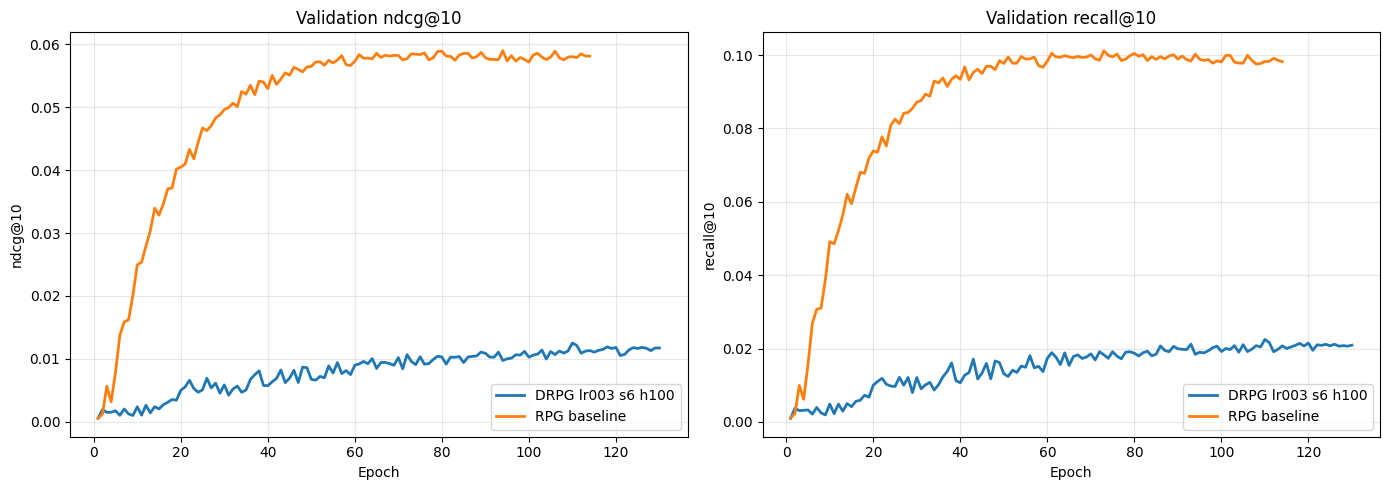

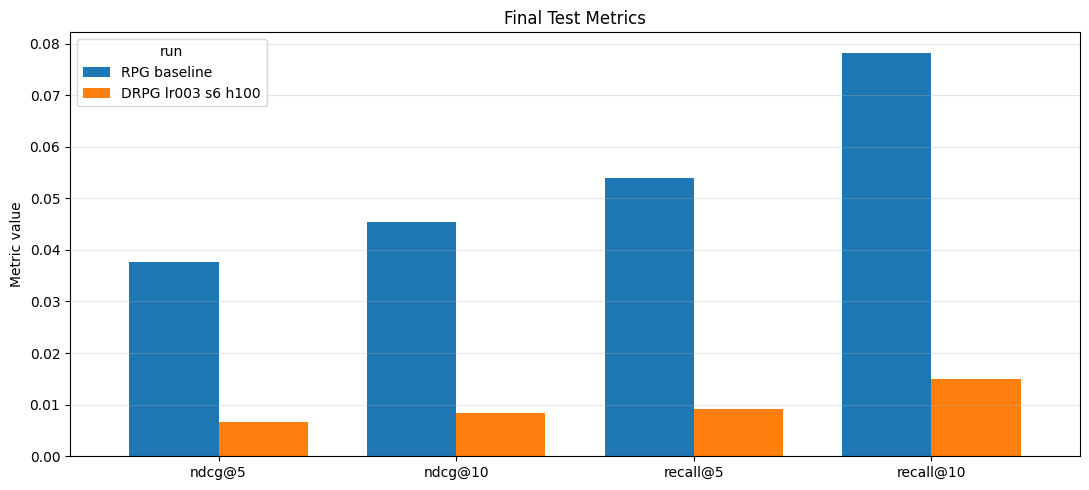

In [4]:
plt.style.use("default")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)
for metric, ax in zip(["ndcg@10", "recall@10"], axes):
    plot_df = curves[(curves["split"] == "val") & (curves["metric"] == metric)]
    for run_name, run_df in plot_df.groupby("run"):
        ax.plot(run_df["epoch"], run_df["value"], label=run_name, linewidth=2)
    ax.set_title(f"Validation {metric}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.tight_layout()
plt.show()

test_metrics = ["test_ndcg@5", "test_ndcg@10", "test_recall@5", "test_recall@10"]
test_plot = summary.set_index("run")[test_metrics].T
ax = test_plot.plot(kind="bar", figsize=(11, 5), width=0.75)
ax.set_title("Final Test Metrics")
ax.set_ylabel("Metric value")
ax.grid(True, axis="y", alpha=0.3)
ax.set_xticklabels([label.replace("test_", "") for label in test_plot.index], rotation=0)
plt.tight_layout()
plt.show()


## Evidence-Based Diagnosis

The DRPG job did not crash. It tokenized the dataset, trained until early stopping, loaded the best checkpoint, initialized the graph, and produced test results. The problem is quality.

The most important evidence is that validation quality is already low before final test-time graph propagation. The DRPG best validation NDCG@10 is around one fifth of the RPG baseline, and the gap appears early in training. Therefore graph propagation may still be worth auditing, but it is unlikely to be the sole cause.

The code areas to inspect first are:

- `models/drpg/model.py::_token_logits_from_denoising`: final logits are recomputed/used for all digits after iterative reveal decisions. This can discard revealed-token confidence and rescore already-decided digits.
- `models/drpg/model.py::_step_to_next_mask_count`: confidence-based reveal order controls the generation trajectory.
- `models/drpg/model.py::_global_to_local_labels`: training converts global semantic-token IDs into per-codebook local labels.
- `models/drpg/model.py::generate`: item logits are computed by gathering flattened token logits and averaging over semantic-ID digits.
- `models/drpg/tokenizer.py::tokenize_function`: train examples use every next-item transition, while validation/test use only the held-out next item.

In [5]:
hypotheses = pd.DataFrame(
    [
        {
            "rank": 1,
            "hypothesis": "Iterative denoising / final-logit handling is misaligned with training views.",
            "evidence": "DRPG learns slowly and peaks far below RPG; generation uses final logits for all digits after reveal steps.",
            "next_check": "Evaluate oracle partial masks and compare last_masked vs extra_refinement on the same checkpoint.",
        },
        {
            "rank": 2,
            "hypothesis": "The denoiser objective is too weak or too noisy for 32-codebook semantic IDs.",
            "evidence": "Loss decreases, but retrieval metrics remain low; all mask-count views are averaged equally.",
            "next_check": "Report per-digit top-1/top-5 target-token accuracy for each mask count.",
        },
        {
            "rank": 3,
            "hypothesis": "Hyperparameters are not comparable to the RPG baseline.",
            "evidence": "The DRPG job overrides lr to 0.003, while the Beauty RPG preset uses lr 0.01.",
            "next_check": "Run short gpu_mig ablations for lr, dropout, label smoothing, and OCN strategy before another full H100 run.",
        },
        {
            "rank": 4,
            "hypothesis": "Semantic-ID labels or item scoring are offset incorrectly.",
            "evidence": "Global-token to local-label conversion and flattened gather indexing are hand-written and high-risk.",
            "next_check": "Unit-test round trips from item ID to semantic tokens to gathered logits to candidate item rank.",
        },
        {
            "rank": 5,
            "hypothesis": "Graph propagation is not the primary issue.",
            "evidence": "Both RPG and DRPG initialize graph propagation for final test, but DRPG validation is already poor.",
            "next_check": "Still compare raw top-k vs graph top-k from the same checkpoint to quantify graph contribution.",
        },
    ]
)

display(hypotheses.style.set_properties(subset=["hypothesis", "evidence", "next_check"], **{"text-align": "left"}))


,rank,hypothesis,evidence,next_check
0,1,Iterative denoising / final-logit handling is misaligned with training views.,DRPG learns slowly and peaks far below RPG; generation uses final logits for all digits after reveal steps.,Evaluate oracle partial masks and compare last_masked vs extra_refinement on the same checkpoint.
1,2,The denoiser objective is too weak or too noisy for 32-codebook semantic IDs.,"Loss decreases, but retrieval metrics remain low; all mask-count views are averaged equally.",Report per-digit top-1/top-5 target-token accuracy for each mask count.
2,3,Hyperparameters are not comparable to the RPG baseline.,"The DRPG job overrides lr to 0.003, while the Beauty RPG preset uses lr 0.01.","Run short gpu_mig ablations for lr, dropout, label smoothing, and OCN strategy before another full H100 run."
3,4,Semantic-ID labels or item scoring are offset incorrectly.,Global-token to local-label conversion and flattened gather indexing are hand-written and high-risk.,Unit-test round trips from item ID to semantic tokens to gathered logits to candidate item rank.
4,5,Graph propagation is not the primary issue.,"Both RPG and DRPG initialize graph propagation for final test, but DRPG validation is already poor.",Still compare raw top-k vs graph top-k from the same checkpoint to quantify graph contribution.


## Pre-Graph Checkpoint Diagnostics

The previous sections are log-only. This section consumes the checkpoint diagnostic JSON generated by `jobs/diagnostics/drpg/pregraph_beauty.sh`. These checks happen before graph propagation and directly test whether the DRPG checkpoint can rank items or predict semantic-ID digits from the validation histories.

The GPU job writes:

```text
artifacts/rpg/diagnostics/drpg_beauty_pregraph_diagnostics.json
```

Submitted job in this branch: `23968849` (`drpg_pregraph_beauty`). If the artifact is missing, rerun the cell after the Slurm job completes.

In [6]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Markdown, display

DIAGNOSTIC_JSON = REPO_ROOT / "artifacts/rpg/diagnostics/drpg_beauty_pregraph_diagnostics.json"

if not DIAGNOSTIC_JSON.is_file():
    display(Markdown(f"**Pre-graph diagnostic artifact is not available yet.** Expected `{DIAGNOSTIC_JSON.relative_to(REPO_ROOT)}`. The GPU job may still be queued/running."))
    diagnostic = None
else:
    diagnostic = json.loads(DIAGNOSTIC_JSON.read_text())
    display(Markdown("### Diagnostic Metadata"))
    display(pd.DataFrame([diagnostic["metadata"]]).T.rename(columns={0: "value"}))

diagnostic is not None


### Diagnostic Metadata

,value
checkpoint,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/ckp...
output_path,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/dia...
max_examples_requested,1024
n_examples,1024
batch_size,64
device,cuda
mask_counts,"[32, 24, 16, 8, 4, 1]"
n_digit,32
codebook_size,256
n_items,12102


True

### Raw Pre-Graph Retrieval

,n_visited_items,ndcg@10,ndcg@5,recall@10,recall@5
mode,,,,,
iterative no graph,12101.0000,0.0037,0.0014,0.0088,0.0020
one-shot all masked,12101.0000,0.0047,0.0040,0.0078,0.0059


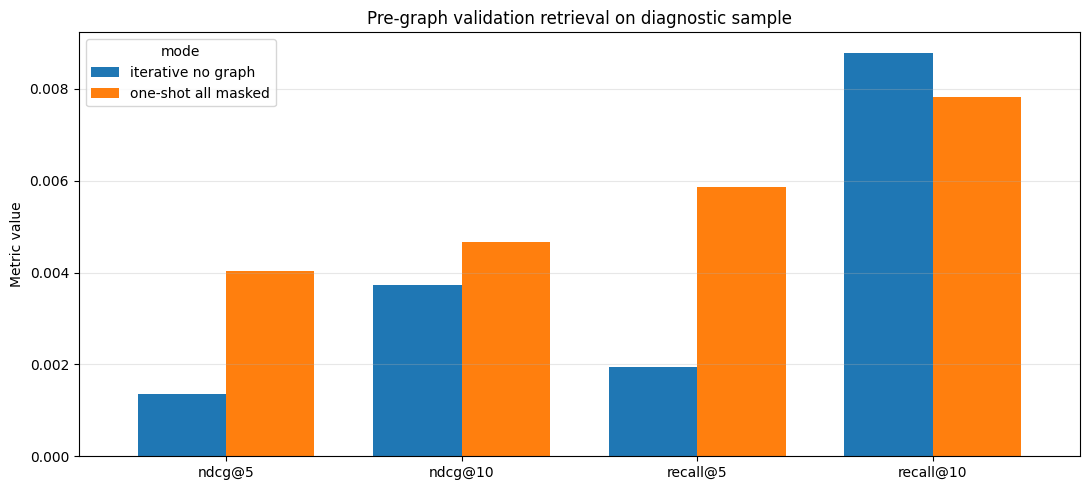

**Comment:** `iterative no graph` tests the actual DRPG denoising schedule without graph propagation. `one-shot all masked` removes the iterative reveal path and asks whether the checkpoint has usable all-token logits at all.

In [7]:
if diagnostic is not None:
    pregraph_metrics = pd.DataFrame(
        [
            {"mode": "iterative no graph", **diagnostic["raw_iterative_no_graph_metrics"]},
            {"mode": "one-shot all masked", **diagnostic["one_shot_all_masked_no_graph_metrics"]},
        ]
    ).set_index("mode")

    display(Markdown("### Raw Pre-Graph Retrieval"))
    display(pregraph_metrics.style.format("{:.4f}"))

    ax = pregraph_metrics[["ndcg@5", "ndcg@10", "recall@5", "recall@10"]].T.plot(
        kind="bar", figsize=(11, 5), width=0.75
    )
    ax.set_title("Pre-graph validation retrieval on diagnostic sample")
    ax.set_ylabel("Metric value")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

    display(Markdown(
        "**Comment:** `iterative no graph` tests the actual DRPG denoising schedule without graph propagation. "
        "`one-shot all masked` removes the iterative reveal path and asks whether the checkpoint has usable all-token logits at all."
    ))


### One-Shot Semantic-ID Accuracy by Digit

,digit,top1_accuracy,top5_accuracy,unique_top1_code_share,most_common_top1_share
0,0,0.007,0.061,0.090,0.791
1,1,0.009,0.054,0.137,0.672
2,2,0.008,0.040,0.113,0.522
3,3,0.006,0.039,0.105,0.327
4,4,0.015,0.046,0.090,0.721
5,5,0.012,0.050,0.125,0.750
6,6,0.012,0.043,0.109,0.662
7,7,0.017,0.060,0.090,0.828
8,8,0.010,0.050,0.125,0.466
9,9,0.010,0.041,0.094,0.760


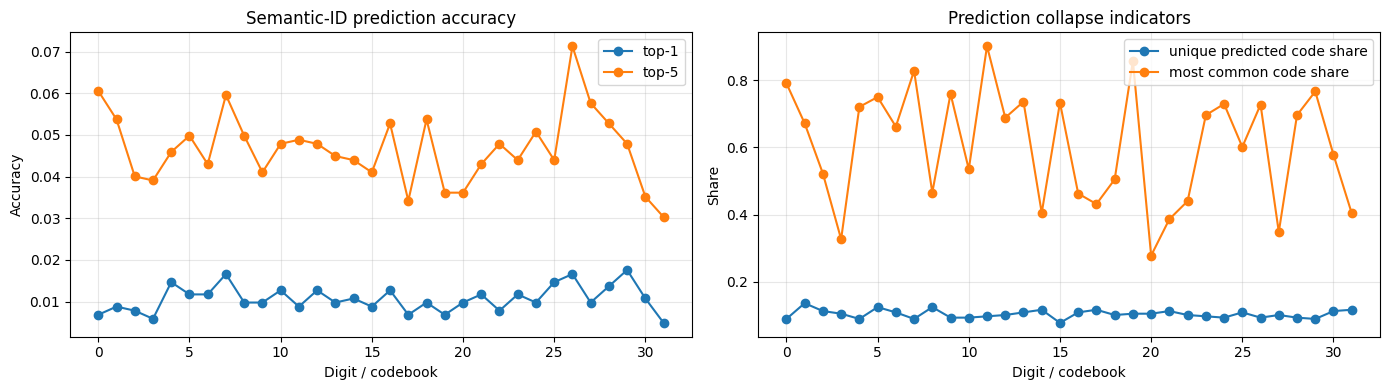

**Comment:** low per-digit accuracy means the failure happens before item ranking. High `most_common_top1_share` or low `unique_top1_code_share` means the denoiser is collapsing toward frequent code priors.

In [8]:
if diagnostic is not None:
    digit_df = pd.DataFrame(diagnostic["one_shot_digit_accuracy"])
    display(Markdown("### One-Shot Semantic-ID Accuracy by Digit"))
    display(
        digit_df[["digit", "top1_accuracy", "top5_accuracy", "unique_top1_code_share", "most_common_top1_share"]]
        .style.format({
            "top1_accuracy": "{:.3f}",
            "top5_accuracy": "{:.3f}",
            "unique_top1_code_share": "{:.3f}",
            "most_common_top1_share": "{:.3f}",
        })
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
    axes[0].plot(digit_df["digit"], digit_df["top1_accuracy"], marker="o", label="top-1")
    axes[0].plot(digit_df["digit"], digit_df["top5_accuracy"], marker="o", label="top-5")
    axes[0].set_title("Semantic-ID prediction accuracy")
    axes[0].set_xlabel("Digit / codebook")
    axes[0].set_ylabel("Accuracy")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(digit_df["digit"], digit_df["unique_top1_code_share"], marker="o", label="unique predicted code share")
    axes[1].plot(digit_df["digit"], digit_df["most_common_top1_share"], marker="o", label="most common code share")
    axes[1].set_title("Prediction collapse indicators")
    axes[1].set_xlabel("Digit / codebook")
    axes[1].set_ylabel("Share")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    display(Markdown(
        "**Comment:** low per-digit accuracy means the failure happens before item ranking. "
        "High `most_common_top1_share` or low `unique_top1_code_share` means the denoiser is collapsing toward frequent code priors."
    ))


### Oracle Suffix-Mask Denoising

,mask_count,revealed_true_digits,evaluated_digits,mean_top1_accuracy,mean_top5_accuracy,mean_unique_top1_code_share
0,32,0,0-31,0.011,0.047,0.104
1,24,8,8-31,0.850,0.927,0.939
2,16,16,16-31,0.912,0.961,0.944
3,8,24,24-31,0.919,0.963,0.938
4,4,28,28-31,0.922,0.965,0.935
5,1,31,31-31,0.976,0.988,0.941


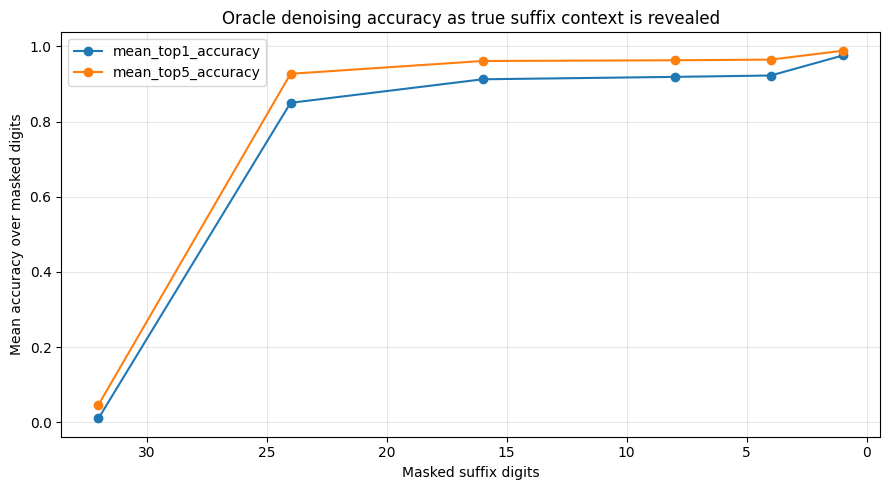

**Comment:** if oracle accuracy improves sharply as fewer suffix digits are masked, the denoiser can use true context but the iterative reveal schedule may be damaging. If oracle accuracy stays low even with few masked digits, the checkpoint has a weaker semantic-ID prediction problem.

In [9]:
if diagnostic is not None:
    oracle_df = pd.DataFrame(diagnostic["oracle_suffix_mask_accuracy"]).sort_values("mask_count", ascending=False)
    display(Markdown("### Oracle Suffix-Mask Denoising"))
    display(
        oracle_df.style.format({
            "mean_top1_accuracy": "{:.3f}",
            "mean_top5_accuracy": "{:.3f}",
            "mean_unique_top1_code_share": "{:.3f}",
        })
    )

    ax = oracle_df.plot(
        x="mask_count",
        y=["mean_top1_accuracy", "mean_top5_accuracy"],
        marker="o",
        figsize=(9, 5),
    )
    ax.invert_xaxis()
    ax.set_title("Oracle denoising accuracy as true suffix context is revealed")
    ax.set_xlabel("Masked suffix digits")
    ax.set_ylabel("Mean accuracy over masked digits")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    display(Markdown(
        "**Comment:** if oracle accuracy improves sharply as fewer suffix digits are masked, the denoiser can use true context but the iterative reveal schedule may be damaging. "
        "If oracle accuracy stays low even with few masked digits, the checkpoint has a weaker semantic-ID prediction problem."
    ))


In [10]:
if diagnostic is not None:
    conf = pd.DataFrame([diagnostic["one_shot_confidence"]])
    display(Markdown("### One-Shot Confidence"))
    display(conf.style.format("{:.4f}"))

    display(Markdown(
        "**Comment:** confidence and entropy help distinguish uncertain predictions from overconfident collapse. "
        "High confidence with poor retrieval usually points to a biased/collapsed distribution; low confidence points to a generally weak denoiser."
    ))


### One-Shot Confidence

,mean_entropy,mean_top1_confidence
0,5.4434,0.0127


**Comment:** confidence and entropy help distinguish uncertain predictions from overconfident collapse. High confidence with poor retrieval usually points to a biased/collapsed distribution; low confidence points to a generally weak denoiser.

## Remasking and Prefix-Constrained Decode Eval

This section consumes the eval-only job generated by `jobs/diagnostics/drpg/remask_decode_beauty.sh`. It tests whether the current trained DRPG checkpoint can be rescued at decoding time by revising committed digits, revealing a small number of true target digits, or using constrained prefix proposals before running the remaining denoising steps.

The GPU job writes:

```text
artifacts/rpg/diagnostics/drpg_beauty_remask_decode_eval.json
```

The updated evaluation uses 1024 Beauty validation examples, graph candidates from the 3 most recent history items with up to 200 neighbors per seed, and multiple reveal counts. The important new question is whether giving DRPG only `8`, `4`, or even `2` true digits is enough to recover the final item. `oracle_prefixN_suffix` reveals the true first `N` digits; `oracle_randomN_suffix` reveals `N` uniformly random true positions per example with the seed recorded in metadata.


In [ ]:
REMASK_JSON = REPO_ROOT / "artifacts/rpg/diagnostics/drpg_beauty_remask_decode_eval.json"

decode_diag = None
reveal_counts = []

if not REMASK_JSON.is_file():
    display(Markdown(f"**Remask decode artifact is not available yet.** Expected `{REMASK_JSON.relative_to(REPO_ROOT)}`. The GPU job may still be queued/running."))
    remask_eval = None
else:
    remask_eval = json.loads(REMASK_JSON.read_text())
    remask_meta = remask_eval["metadata"]
    reveal_counts = remask_meta.get("reveal_counts")
    if reveal_counts is None:
        legacy_prefix_len = remask_meta.get("prefix_len")
        reveal_counts = [legacy_prefix_len] if legacy_prefix_len is not None else []
    if "decode_diagnostics" in remask_eval:
        decode_diag = pd.DataFrame(remask_eval["decode_diagnostics"])
    display(Markdown("### Remask Decode Metadata"))
    display(pd.DataFrame([remask_meta]).T.rename(columns={0: "value"}))


In [ ]:
if remask_eval is not None:
    strategy_metrics = pd.DataFrame(remask_eval["strategy_metrics"])
    metric_cols = ["ndcg@5", "ndcg@10", "recall@5", "recall@10", "n_visited_items"]
    show_cols = [col for col in ["strategy", "reveal_policy", "reveal_count", *metric_cols] if col in strategy_metrics.columns]
    strategy_metrics = strategy_metrics[show_cols].sort_values(["ndcg@10", "reveal_count"], ascending=[False, False])

    display(Markdown("### Decode Strategy Metrics"))
    display(strategy_metrics.style.format({col: "{:.4f}" for col in metric_cols}))

    if {"reveal_policy", "reveal_count", "ndcg@10", "recall@10"}.issubset(strategy_metrics.columns):
        oracle_metrics = strategy_metrics[strategy_metrics["reveal_policy"].isin(["oracle_prefix", "oracle_random"])].copy()
        if not oracle_metrics.empty:
            plot_df = oracle_metrics.pivot(index="reveal_count", columns="reveal_policy", values="ndcg@10").sort_index()
            ax = plot_df.plot(marker="o", figsize=(8, 4))
            ax.set_title("Oracle decode quality vs number of revealed true digits")
            ax.set_xlabel("revealed true digits")
            ax.set_ylabel("NDCG@10")
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


**Comment:** the oracle rows are the clean upper bounds. `oracle_prefixN_suffix` tells us how valuable the leading SID digits are; `oracle_randomN_suffix` asks a harder question: if we grant DRPG only `N` correct anchors in arbitrary positions, can it still recover the item by the end? The `N=4` and `N=2` rows are the most informative new checks.

In [ ]:
if remask_eval is not None:
    if decode_diag is None:
        prefix_accuracy = pd.DataFrame(remask_eval["prefix_accuracy"])
        display(Markdown("### Legacy Prefix Accuracy"))
        display(prefix_accuracy.style.format("{:.4f}"))
    else:
        diag_cols = [
            "strategy",
            "reveal_policy",
            "reveal_count",
            "input_revealed_accuracy",
            "completed_unrevealed_accuracy",
            "final_digit_accuracy",
            "final_sid_exact_match",
            "target_item_top1_accuracy",
        ]
        diag_view = decode_diag[diag_cols].sort_values(["reveal_policy", "reveal_count"], ascending=[True, False])
        display(Markdown("### Reveal-Conditioned Completion Diagnostics"))
        display(diag_view.style.format({
            "input_revealed_accuracy": "{:.4f}",
            "completed_unrevealed_accuracy": "{:.4f}",
            "final_digit_accuracy": "{:.4f}",
            "final_sid_exact_match": "{:.4f}",
            "target_item_top1_accuracy": "{:.4f}",
        }))

        oracle_diag = decode_diag[decode_diag["reveal_policy"].isin(["oracle_prefix", "oracle_random"])].copy()
        if not oracle_diag.empty:
            fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

            sid_plot = oracle_diag.pivot(index="reveal_count", columns="reveal_policy", values="final_sid_exact_match").sort_index()
            sid_plot.plot(marker="o", ax=axes[0])
            axes[0].set_title("Exact final SID match")
            axes[0].set_xlabel("revealed true digits")
            axes[0].set_ylabel("exact-match rate")
            axes[0].grid(True, alpha=0.3)

            suffix_plot = oracle_diag.pivot(index="reveal_count", columns="reveal_policy", values="completed_unrevealed_accuracy").sort_index()
            suffix_plot.plot(marker="o", ax=axes[1])
            axes[1].set_title("Accuracy on unrevealed digits after decode")
            axes[1].set_xlabel("revealed true digits")
            axes[1].set_ylabel("digit accuracy")
            axes[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()


**Comment:** this table answers the real question more directly than ranking metrics alone. `completed_unrevealed_accuracy` tells us how well DRPG fills in the missing digits once some anchors are supplied, while `final_sid_exact_match` and `target_item_top1_accuracy` tell us whether the whole item is actually recovered. If random-4 is already strong, then any four correct anchors may be enough; if random-2 stays near zero, then two anchors are not sufficient to rescue the decode.

In [14]:
if remask_eval is not None and remask_eval.get("graph_candidate_pool") is not None:
    graph_pool = pd.DataFrame([remask_eval["graph_candidate_pool"]]).T.rename(columns={0: "value"})
    display(Markdown("### Graph Candidate Pool Recall"))
    display(graph_pool.style.format("{:.4f}"))


### Graph Candidate Pool Recall

,value
mean_pool_size,580.2041
true_item_recall,0.1689
n_examples,1024.0000


**Comment:** graph-prefix decoding can only work if the true next item is inside the graph candidate pool often enough. Low pool recall means the graph is constraining the search to the wrong region, even before DRPG reranking or suffix demasking.

In [ ]:
if remask_eval is not None:
    key_metrics = strategy_metrics.set_index("strategy")[["ndcg@10", "recall@10"]].copy()
    oracle_rows = [idx for idx in key_metrics.index if idx.startswith("oracle_")]
    deployable = key_metrics.drop(index=oracle_rows, errors="ignore")
    best_deployable = deployable.sort_values("ndcg@10", ascending=False).head(1)
    current = key_metrics.loc[["monotonic_current"]] if "monotonic_current" in key_metrics.index else None
    display(Markdown("### Decode Eval Read"))
    display(Markdown(
        f"Best deployable strategy by NDCG@10: **{best_deployable.index[0]}** "
        f"with NDCG@10 `{best_deployable['ndcg@10'].iloc[0]:.4f}` and Recall@10 `{best_deployable['recall@10'].iloc[0]:.4f}`."
    ))
    if current is not None:
        display(Markdown(
            f"Current monotonic DRPG: NDCG@10 `{current['ndcg@10'].iloc[0]:.4f}`, "
            f"Recall@10 `{current['recall@10'].iloc[0]:.4f}`."
        ))

    if decode_diag is not None and {"reveal_policy", "reveal_count", "final_sid_exact_match", "target_item_top1_accuracy"}.issubset(decode_diag.columns):
        oracle_diag = decode_diag[decode_diag["reveal_policy"].isin(["oracle_prefix", "oracle_random"])].copy()
        for policy, label in [("oracle_prefix", "Oracle leading-prefix"), ("oracle_random", "Oracle random-anchor")]:
            subset = oracle_diag[oracle_diag["reveal_policy"] == policy].sort_values("reveal_count", ascending=False)
            if subset.empty:
                continue
            summary = "; ".join(
                f"{int(row.reveal_count)} digits -> exact SID `{row.final_sid_exact_match:.4f}`, top-1 item `{row.target_item_top1_accuracy:.4f}`"
                for row in subset.itertuples()
            )
            display(Markdown(f"{label}: {summary}."))


## Consolidated Failure Summary

This section compresses the log, pre-graph, oracle-prefix, remasking, and graph-candidate diagnostics into one diagnosis. The important distinction is between **suffix demasking ability** and **prefix proposal ability**: the checkpoint can complete a semantic ID once enough correct digits are supplied, but the deployable decoder almost never proposes those anchors on its own.

In [ ]:
if diagnostic is not None and remask_eval is not None:
    pre = diagnostic["raw_iterative_no_graph_metrics"]
    one = diagnostic["one_shot_all_masked_no_graph_metrics"]
    digit_df = pd.DataFrame(diagnostic["one_shot_digit_accuracy"])
    oracle8 = next(row for row in diagnostic["oracle_suffix_mask_accuracy"] if row["revealed_true_digits"] == 8)
    strat = pd.DataFrame(remask_eval["strategy_metrics"]).set_index("strategy")
    graph_pool = remask_eval.get("graph_candidate_pool") or {}

    problem_rows = [
        {
            "problem": "Failure is pre-graph, not a Slurm/runtime crash",
            "evidence": f"Raw iterative pre-graph NDCG@10 is {pre['ndcg@10']:.4f}; one-shot all-masked NDCG@10 is {one['ndcg@10']:.4f}.",
            "interpretation": "The checkpoint quality is already poor before final graph propagation.",
        },
        {
            "problem": "All-masked prediction collapses / is nearly random",
            "evidence": f"Mean all-masked digit top-1 is {digit_df['top1_accuracy'].mean():.4f}; top-5 is {digit_df['top5_accuracy'].mean():.4f}; most-common predicted code share averages {digit_df['most_common_top1_share'].mean():.4f}.",
            "interpretation": "The first denoising step does not recover item identity and often favors frequent code priors.",
        },
        {
            "problem": "Suffix demasking is strong if a true prefix is supplied",
            "evidence": f"With 8 true digits revealed, suffix top-1 is {oracle8['mean_top1_accuracy']:.4f} and top-5 is {oracle8['mean_top5_accuracy']:.4f}.",
            "interpretation": "The denoiser has useful conditional completion behavior; the issue is not the whole denoiser.",
        },
        {
            "problem": "Graph candidates help ranking but are too narrow/weak as prefix source",
            "evidence": f"Graph candidate rerank is the best deployable strategy at NDCG@10 {strat.loc['graph_history_candidate_rerank', 'ndcg@10']:.4f}, but true-item pool recall is only {graph_pool.get('true_item_recall', float('nan')):.4f} with mean pool size {graph_pool.get('mean_pool_size', float('nan')):.1f}.",
            "interpretation": "The graph provides signal, but it often excludes the target item and therefore caps any graph-prefix decoder.",
        },
        {
            "problem": "Naive confidence remasking is not enough",
            "evidence": f"Confidence reselect/remask NDCG@10 is {strat.loc['confidence_reselect_remask', 'ndcg@10']:.4f}, below monotonic current {strat.loc['monotonic_current', 'ndcg@10']:.4f}.",
            "interpretation": "Confidence alone cannot reliably identify early wrong digits; we need structural checks or a better proposal distribution.",
        },
    ]

    if decode_diag is not None and {"strategy", "reveal_policy", "reveal_count", "final_sid_exact_match", "target_item_top1_accuracy", "input_revealed_accuracy"}.issubset(decode_diag.columns):
        oracle_random = decode_diag[decode_diag["reveal_policy"] == "oracle_random"].set_index("reveal_count")
        oracle_prefix = decode_diag[decode_diag["reveal_policy"] == "oracle_prefix"].set_index("reveal_count")
        predicted_prefix = decode_diag[decode_diag["reveal_policy"] == "predicted_prefix"].set_index("reveal_count")

        available_random = sorted(oracle_random.index.tolist(), reverse=True)
        if available_random:
            best_random = available_random[0]
            smallest_random = available_random[-1]
            problem_rows.append(
                {
                    "problem": "Random true anchors reveal the anchor-count threshold",
                    "evidence": f"Random-{best_random} reaches exact SID match {oracle_random.loc[best_random, 'final_sid_exact_match']:.4f} and top-1 item {oracle_random.loc[best_random, 'target_item_top1_accuracy']:.4f}; random-{smallest_random} reaches exact SID match {oracle_random.loc[smallest_random, 'final_sid_exact_match']:.4f} and top-1 item {oracle_random.loc[smallest_random, 'target_item_top1_accuracy']:.4f}.",
                    "interpretation": "This isolates how many correct anchors DRPG needs before the suffix denoiser can finish the job.",
                }
            )

        if 4 in oracle_random.index:
            problem_rows.append(
                {
                    "problem": "Random-4 oracle is the key middle-ground diagnostic",
                    "evidence": f"Random-4 gives exact SID match {oracle_random.loc[4, 'final_sid_exact_match']:.4f} and top-1 item {oracle_random.loc[4, 'target_item_top1_accuracy']:.4f}; prefix-4 gives exact SID match {oracle_prefix.loc[4, 'final_sid_exact_match']:.4f}.",
                    "interpretation": "The gap between random-4 and prefix-4 tells us whether four correct digits are enough in general, or whether the earliest positions are disproportionately important.",
                }
            )

        predicted_rows = predicted_prefix.reset_index()
        if not predicted_rows.empty:
            best_pred = predicted_rows.sort_values("reveal_count", ascending=False).iloc[0]
            problem_rows.append(
                {
                    "problem": "Deployable prefix proposals are wrong even before suffix completion",
                    "evidence": f"Predicted prefix-{int(best_pred['reveal_count'])} revealed-digit accuracy is {best_pred['input_revealed_accuracy']:.4f}.",
                    "interpretation": "The decoder still fails at the anchor proposal stage, which explains why the oracle upper bounds are far above deployable decoding.",
                }
            )

    problem_summary = pd.DataFrame(problem_rows)
    display(Markdown("### Problems Found"))
    display(problem_summary)


## Literature-Grounded Solution Direction

The closest literature says early committed mistakes are the central weakness of masked/parallel discrete generation. Mask-Predict and MaskGIT use iterative confidence-based masking/unmasking; DiffGRM adapts this family to semantic-ID recommendation with confidence-guided parallel denoising; recent masked-diffusion language-model work argues that simple confidence remasking is setting-dependent and that better policies should remask suspect tokens, decouple detection from regeneration, and avoid conditioning regeneration on known-bad tokens.

Sources used: [Mask-Predict](https://arxiv.org/abs/1904.09324), [MaskGIT](https://arxiv.org/abs/2202.04200), [DiffGRM](https://arxiv.org/abs/2510.21805), [DiffGRM code](https://github.com/liuzhao09/DiffGRM), [Remask, Don't Replace](https://arxiv.org/abs/2604.18738), [NAVIRA](https://arxiv.org/abs/2606.06031), and [Re-evaluating Confidence Remasking](https://arxiv.org/abs/2606.12232).

In [17]:
literature_rows = [
    {
        "source": "Mask-Predict / MaskGIT",
        "relevant idea": "Iteratively predict many masked tokens, keep high-confidence tokens, and revisit low-confidence positions.",
        "implication for DRPG": "Our monotonic reveal schedule is plausible, but confidence alone is weak when the all-masked distribution collapses.",
    },
    {
        "source": "DiffGRM",
        "relevant idea": "Confidence-guided parallel denoising and beam-style candidate generation for semantic IDs.",
        "implication for DRPG": "Borrow CPD/beam diversity, but adapt it to 32 digits; DiffGRM examples use short n_digit=4 SIDs, so plain beam search is likely too loose here.",
    },
    {
        "source": "Remask, Don't Replace",
        "relevant idea": "When a token is suspect, reset it to MASK rather than overwriting it with another possibly wrong token.",
        "implication for DRPG": "Use token-to-mask refinement for bad prefix digits; do not keep feeding coherent but wrong prefixes as context.",
    },
    {
        "source": "NAVIRA",
        "relevant idea": "Decouple detection from regeneration: score suspect tokens, mask them, then run a fresh forward pass from cleaned context.",
        "implication for DRPG": "A two-pass detect-remask-regenerate policy is more principled than reselecting digits in the same forward pass.",
    },
    {
        "source": "Recent confidence-remasking reevaluation",
        "relevant idea": "Post-hoc confidence remasking can provide little benefit and can worsen collapse depending on decoding settings.",
        "implication for DRPG": "Our failed confidence-remask eval is not surprising; structural validity and candidate recall should drive remasking decisions.",
    },
]

literature_df = pd.DataFrame(literature_rows)
display(Markdown("### What the Literature Suggests"))
display(literature_df)


### What the Literature Suggests

,source,relevant idea,implication for DRPG
0,Mask-Predict / MaskGIT,"Iteratively predict many masked tokens, keep h...","Our monotonic reveal schedule is plausible, bu..."
1,DiffGRM,Confidence-guided parallel denoising and beam-...,"Borrow CPD/beam diversity, but adapt it to 32 ..."
2,"Remask, Don't Replace","When a token is suspect, reset it to MASK rath...",Use token-to-mask refinement for bad prefix di...
3,NAVIRA,Decouple detection from regeneration: score su...,A two-pass detect-remask-regenerate policy is ...
4,Recent confidence-remasking reevaluation,Post-hoc confidence remasking can provide litt...,Our failed confidence-remask eval is not surpr...


In [18]:
solution_rows = [
    {
        "priority": 1,
        "proposal": "Valid-prefix stochastic remasking",
        "mechanism": "Maintain a beam of first-8 prefixes; reject prefixes that have no catalog support; remask low-confidence or structurally impossible digits; regenerate from MASK.",
        "why this matches evidence": "Oracle prefix-8 works, but predicted/catalog/graph prefix-8 accuracy is ~1%. The first task is to produce a plausible prefix, not to improve suffix completion.",
    },
    {
        "priority": 2,
        "proposal": "Broaden candidate generation before graph-prefix decoding",
        "mechanism": "Measure candidate recall for last-1, last-3, 2-hop graph, RPG/SASRec candidates, global popular fallback, and unions of these pools before applying DRPG reranking.",
        "why this matches evidence": "Current graph pool recall is only ~17%; graph constraints cannot recover targets outside the pool.",
    },
    {
        "priority": 3,
        "proposal": "Decoupled detect-remask-regenerate loop",
        "mechanism": "First pass detects unstable/suspect prefix digits using confidence, probe disagreement, and catalog/graph-prefix validity. Second pass masks only those digits and regenerates.",
        "why this matches evidence": "Naive confidence remasking underperforms; detection needs structural signals and regeneration should not condition on known-bad tokens.",
    },
    {
        "priority": 4,
        "proposal": "Training objective aligned to early-prefix recovery",
        "mechanism": "Overweight all-masked and first-8-prefix losses, add candidate/prefix contrastive loss, or train with self-generated corrupted prefixes so the denoiser learns to repair its own early mistakes.",
        "why this matches evidence": "The checkpoint completes true prefixes but cannot infer them from history; this is a proposal/objective mismatch, not only an inference bug.",
    },
]

solution_df = pd.DataFrame(solution_rows).set_index("priority")
display(Markdown("### Recommended Solution Path"))
display(solution_df)


### Recommended Solution Path

,proposal,mechanism,why this matches evidence
priority,,,
1,Valid-prefix stochastic remasking,Maintain a beam of first-8 prefixes; reject pr...,"Oracle prefix-8 works, but predicted/catalog/g..."
2,Broaden candidate generation before graph-pref...,"Measure candidate recall for last-1, last-3, 2...",Current graph pool recall is only ~17%; graph ...
3,Decoupled detect-remask-regenerate loop,First pass detects unstable/suspect prefix dig...,Naive confidence remasking underperforms; dete...
4,Training objective aligned to early-prefix rec...,Overweight all-masked and first-8-prefix losse...,The checkpoint completes true prefixes but can...


## Recommended Next Experiments

Run these in order, because the first two can explain failure without another expensive full training run.

1. Checkpoint-only diagnostic: load the saved DRPG checkpoint and report raw vs graph metrics, per-digit target-token accuracy, and oracle partial-mask accuracy.
2. Multi-count decode-only ablation: evaluate the same checkpoint with revealed true-digit counts `8,4,2`, paying special attention to `oracle_random4_suffix` and `oracle_random2_suffix` exact-match/top-1 behavior.
3. Decode-only follow-up if random-4 works: design a proposal policy that can generate four plausible anchors, then let the existing suffix denoiser finish.
4. Short training ablations on `gpu_mig`: `lr=0.01`, lower dropout, no label smoothing, `diffusion_ocn_strategy=random`, and a smaller mask schedule.
5. Only after a short ablation improves validation NDCG@10, scale to `gpu_a100` or `gpu_h100`.

A good stopping rule for the cheap jobs: if validation NDCG@10 is not clearly above `0.02` by epoch 30 on Beauty, it is probably not worth a full 24-hour H100 run.
